## What is a Molecular Scaffold?

A molecular scaffold is the core structural framework of a molecule obtained after removing most terminal side chains while retaining the ring systems and the linkers connecting them.

The scaffold represents the central architecture on which different substituents are attached.

Compounds sharing the same scaffold often belong to the same chemical series.

## Chemist's Perspective

Medicinal chemists are usually less interested in the entire molecule than in its core framework.

Typical questions include:

- Which scaffold is responsible for biological activity?
- Can the scaffold be retained while modifying substituents?
- Which scaffold appears most frequently among active compounds?
- Can a new scaffold improve potency or selectivity?

Scaffold analysis forms the basis of Structure–Activity Relationship (SAR) studies and lead optimization.

## Why Do We Need Bemis–Murcko Scaffolds?

Earlier, we learned that a molecular scaffold is the core framework of a molecule.

However, an important question remains:

How does a computer decide which atoms belong to the scaffold and which atoms should be removed?

To solve this problem, Bemis and Murcko proposed a systematic method for extracting the molecular scaffold.

Today, this method is the standard approach used in cheminformatics and is implemented in RDKit.

## What Does the Bemis–Murcko Scaffold Retain?

The Bemis–Murcko algorithm keeps:

- Ring systems
- Linkers connecting ring systems

It removes:

- Terminal side chains
- Small substituents attached to the scaffold

## Chemist's Perspective

Medicinal chemists often synthesize hundreds of analogues based on one scaffold.

Although substituents differ,

the scaffold remains constant.

This allows researchers to study how modifications influence:

- Potency
- Selectivity
- Solubility
- Toxicity
- Pharmacokinetics

without changing the fundamental chemical framework.

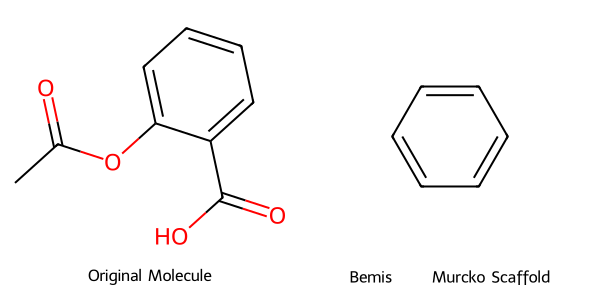

In [1]:
# Example
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold

# Create Aspirin molecule
aspirin = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")

# Extract Bemis–Murcko scaffold
scaffold = MurckoScaffold.GetScaffoldForMol(aspirin)

# Display original molecule and scaffold side by side
Draw.MolsToGridImage(
    [aspirin, scaffold],
    legends=["Original Molecule", "Bemis–Murcko Scaffold"],
    molsPerRow=2,
    subImgSize=(300, 300)
)

# How does RDKit decide the scaffold?

Rule 1: Keep all ring systems ✅
Every ring in the molecule is retained.
Rule 2: Keep linkers connecting rings ✅
If two rings are connected by a chain, the connecting atoms are also retained.
Rule 3: Remove terminal side chains ❌
Anything attached to the scaffold that does not connect two ring systems is removed.

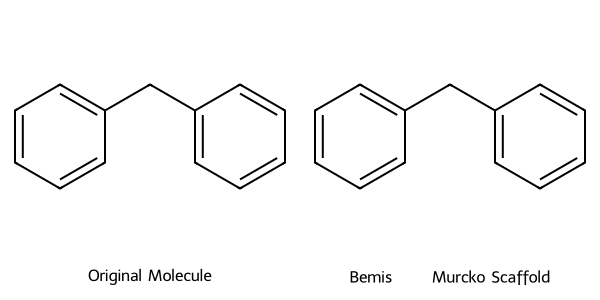

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold

# Diphenylmethane
mol = Chem.MolFromSmiles("c1ccccc1Cc2ccccc2")

# Extract scaffold
scaffold = MurckoScaffold.GetScaffoldForMol(mol)

# Display both molecules
Draw.MolsToGridImage(
    [mol, scaffold],
    legends=["Original Molecule", "Bemis–Murcko Scaffold"],
    molsPerRow=2,
    subImgSize=(300,300)
)

In [5]:
# Examples

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
import pandas as pd

# List of drugs
drugs = {
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Paracetamol": "CC(=O)NC1=CC=C(C=C1)O",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O",
    "Naproxen": "COc1ccc2cc([C@@H](C)C(=O)O)ccc2c1",
    "Diclofenac": "O=C(O)Cc1ccccc1Nc2c(Cl)cccc2Cl",
    "Celecoxib": "CC1=CC(C)=NN1c2ccc(S(N)(=O)=O)cc2",
    "Caffeine": "Cn1cnc2n(C)c(=O)n(C)c(=O)c12",
    "Benzocaine": "CCOC(=O)c1ccc(N)cc1"
}

results = []

molecules = []
scaffolds = []
legends = []

for name, smiles in drugs.items():

    mol = Chem.MolFromSmiles(smiles)

    scaffold = MurckoScaffold.GetScaffoldForMol(mol)

    results.append({
        "Drug": name,
        "Scaffold SMILES": Chem.MolToSmiles(scaffold)
    })

    molecules.extend([mol, scaffold])

    legends.extend([
        name,
        "Scaffold"
    ])

df = pd.DataFrame(results)

df

,Drug,Scaffold SMILES
0,Aspirin,c1ccccc1
1,Paracetamol,c1ccccc1
2,Ibuprofen,c1ccccc1
3,Naproxen,c1ccc2ccccc2c1
4,Diclofenac,c1ccc(Nc2ccccc2)cc1
5,Celecoxib,c1ccc(-n2cccn2)cc1
6,Caffeine,O=c1[nH]c(=O)c2[nH]cnc2[nH]1
7,Benzocaine,c1ccccc1


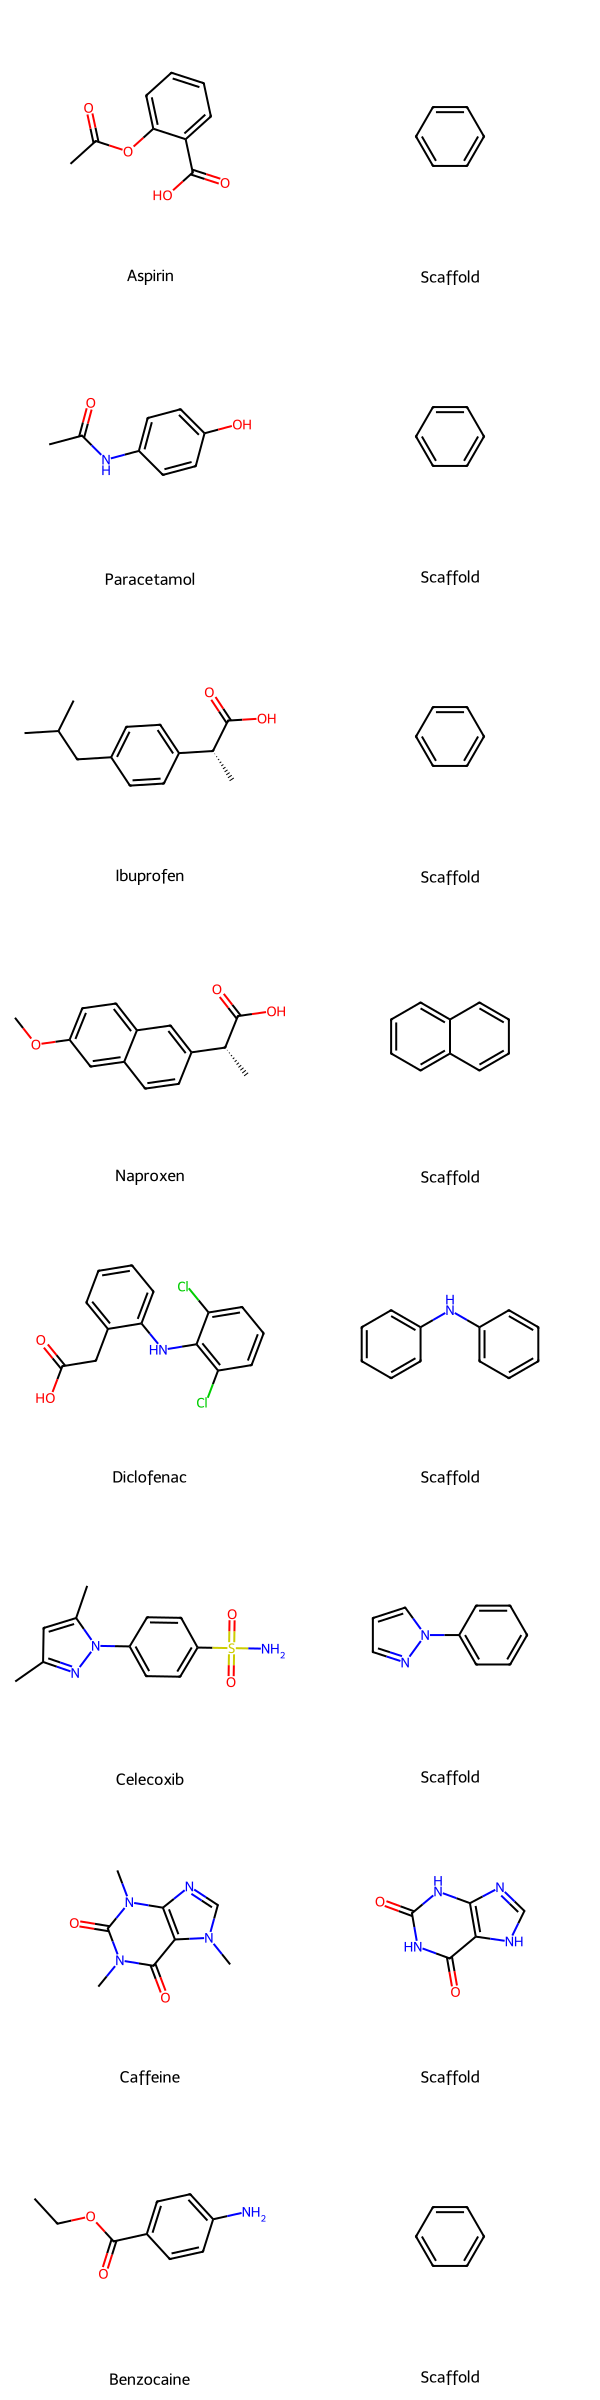

In [6]:
Draw.MolsToGridImage(
    molecules,
    legends=legends,
    molsPerRow=2,
    subImgSize=(300,300)
)

## Observations

After extracting the Bemis–Murcko scaffolds, several interesting patterns can be observed:

- Aspirin, Paracetamol, Ibuprofen, and Benzocaine all contain a benzene-based scaffold, despite having different substituents and therapeutic uses.
- Naproxen retains a fused aromatic ring system, reflecting its more complex core structure.
- Diclofenac contains a biphenyl-like scaffold connected through the central framework.
- Celecoxib retains a pyrazole-containing scaffold, which is characteristic of selective COX-2 inhibitors.
- Caffeine retains its fused heterocyclic xanthine scaffold.

This demonstrates that scaffold analysis groups molecules according to their core structural framework rather than their side chains.